<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
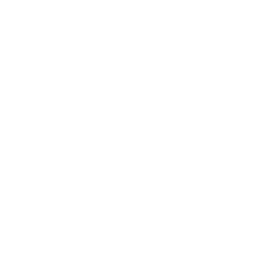
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">ゲノムバリアントアノテーションのスキーマドキュメント</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; バイオインフォマティクス / 臨床ゲノミクスデータ管理 &nbsp;|&nbsp; 2026年3月</p>
</div>
</div>
</div>

## エグゼクティブサマリー

臨床ゲノミクスパイプラインで使用される VCF 形式のバリアントアノテーションデータセットのスキーマを文書化します。PROC CONTENTS を使用して、ゲノム座標、アレル頻度、予測される機能的影響、ClinVar 分類、品質指標といったすべてのアノテーションフィールドをカタログ化し、下流の ACMG バリアント解釈ツールが正しく型付けされラベル付けされた入力を受け取れるようにします。パイプラインへの引き渡し前に、20 列以上のアノテーション列を持つ約 5,000 件のバリアントレコードについてスキーマの整合性を検査します。

## データソース

| ソース | 説明 | レコード数 |
|--------|-------------|--------|
| VARIANT_ANNOTATIONS | VCF から得られたアノテーション付きバリアント | ~5,000 |
| GENE_PANEL | 対象遺伝子パネルの定義 | ~150 遺伝子 |
| QUALITY_METRICS | サンプルごとのシーケンシング QC | ~50 サンプル |

---

In [1]:
/* --------------------------------------------------------
   VCF 形式のバリアントアノテーションデータセットを生成
   臨床アノテーション項目を持つ5,000件のバリアント
   -------------------------------------------------------- */
データ variant_annotations;
    呼出 streaminit(42);
    長さ variant_id $20 chromosome $5 position 8
           ref_allele $10 alt_allele $10 gene_symbol $15
           transcript_id $20 consequence $30
           impact $10 hgvs_c $25 hgvs_p $25
           gnomad_af 8 clinvar_class $25 clinvar_id $12
           sift_score 8 sift_pred $15
           polyphen_score 8 polyphen_pred $15
           cadd_phred 8 revel_score 8
           genotype $5 allele_depth 8 read_depth 8
           qual_score 8 filter_status $10;
    見出 variant_id='バリアント識別子'
          chromosome='染色体'
          position='ゲノム位置 (GRCh38)'
          ref_allele='参照アレル'
          alt_allele='変異アレル'
          gene_symbol='HGNC 遺伝子記号'
          transcript_id='Ensembl 転写産物 ID'
          consequence='Sequence Ontology 影響'
          impact='予測影響度'
          hgvs_c='HGVS コーディング表記'
          hgvs_p='HGVS タンパク質表記'
          gnomad_af='gnomAD アレル頻度'
          clinvar_class='ClinVar 分類'
          clinvar_id='ClinVar 登録番号'
          sift_score='SIFT スコア'
          sift_pred='SIFT 予測'
          polyphen_score='PolyPhen-2 スコア'
          polyphen_pred='PolyPhen-2 予測'
          cadd_phred='CADD Phred スコア'
          revel_score='REVEL アンサンブルスコア'
          genotype='サンプル遺伝子型'
          allele_depth='変異アレルデプス'
          read_depth='総リードデプス'
          qual_score='バリアント品質スコア'
          filter_status='フィルターステータス';
    配列 genes[15] $15 _temporary_ ('BRCA1' 'BRCA2' 'TP53' 'EGFR'
        'KRAS' 'PIK3CA' 'PTEN' 'APC' 'MLH1' 'MSH2' 'ATM'
        'CHEK2' 'PALB2' 'RAD51C' 'RAD51D');
    配列 conseqs[6] $30 _temporary_ ('missense_variant'
        'synonymous_variant' 'frameshift_variant'
        'stop_gained' 'splice_donor_variant' 'intron_variant');
    配列 impacts[6] $10 _temporary_ ('MODERATE' 'LOW' 'HIGH'
        'HIGH' 'HIGH' 'MODIFIER');
    配列 cv_classes[5] $25 _temporary_ ('Pathogenic'
        'Likely_pathogenic' 'Uncertain_significance'
        'Likely_benign' 'Benign');
    配列 refs[4] $1 _temporary_ ('A' 'C' 'G' 'T');
    配列 gts[3] $5 _temporary_ ('0/1' '1/1' '0/0');
    繰返 i = 1 から 5000;
        variant_id = cat('VAR-', PUT(i, z8.));
        chr_num = int(rand('uniform') * 22) + 1;
        chromosome = cat('chr', PUT(chr_num, 2.));
        position = int(rand('uniform') * 200000000) + 10000;
        r_idx = int(rand('uniform') * 4) + 1;
        a_idx = mod(r_idx, 4) + 1;
        ref_allele = refs[r_idx];
        alt_allele = refs[a_idx];
        g_idx = int(rand('uniform') * 15) + 1;
        gene_symbol = genes[g_idx];
        transcript_id = cat('ENST00000', PUT(int(rand('uniform') * 99999) + 100000, z6.));
        c_idx = int(rand('uniform') * 6) + 1;
        consequence = conseqs[c_idx];
        impact = impacts[c_idx];
        codon_pos = int(rand('uniform') * 2000) + 1;
        hgvs_c = cat('c.', PUT(codon_pos, 4.), ref_allele, '>', alt_allele);
        もし c_idx <= 2 なら
            hgvs_p = cat('p.', PUT(int(rand('uniform') * 800) + 1, 4.));
        他 hgvs_p = 'p.?';
        gnomad_af = round(rand('beta', 0.5, 500), 0.000001);
        cv_idx = int(rand('uniform') * 5) + 1;
        clinvar_class = cv_classes[cv_idx];
        clinvar_id = cat('RCV', PUT(int(rand('uniform') * 900000) + 100000, z6.));
        sift_score = round(rand('uniform'), 0.001);
        もし sift_score < 0.05 なら sift_pred = 'DELETERIOUS';
        他 sift_pred = 'TOLERATED';
        polyphen_score = round(rand('uniform'), 0.001);
        もし polyphen_score > 0.908 なら polyphen_pred = 'PROB_DAMAGING';
        他 もし polyphen_score > 0.446 なら polyphen_pred = 'POSS_DAMAGING';
        他 polyphen_pred = 'BENIGN';
        cadd_phred = round(rand('uniform') * 40, 0.01);
        revel_score = round(rand('uniform'), 0.001);
        gt_idx = int(rand('uniform') * 3) + 1;
        genotype = gts[gt_idx];
        read_depth = int(rand('uniform') * 200) + 20;
        allele_depth = int(read_depth * (0.3 + rand('uniform') * 0.4));
        qual_score = round(rand('uniform') * 5000 + 100, 0.1);
        filter_status = ifc(qual_score > 500, 'PASS', 'LOW_QUAL');
        出力;
    終了;
    削除 i chr_num r_idx a_idx g_idx c_idx cv_idx gt_idx codon_pos;
実行;


NOTE: DATA variant_annotations

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote variant_annotations (100 rows, 25 columns).
NOTE: DATA elapsed:
  wall  3.16 seconds
  cpu   3.16 seconds


In [2]:
/* --------------------------------------------------------
   対象遺伝子パネルの定義を生成
   -------------------------------------------------------- */
データ gene_panel;
    呼出 streaminit(42);
    長さ gene_symbol $15 gene_name $60 chromosome $5
           start_pos 8 end_pos 8 panel_name $30
           disease_association $50 inheritance $5;
    見出 gene_symbol='HGNC 遺伝子記号'
          gene_name='遺伝子正式名称'
          chromosome='染色体'
          start_pos='遺伝子開始位置'
          end_pos='遺伝子終了位置'
          panel_name='臨床遺伝子パネル'
          disease_association='関連疾患'
          inheritance='遺伝形式';
    配列 genes[15] $15 _temporary_ ('BRCA1' 'BRCA2' 'TP53' 'EGFR'
        'KRAS' 'PIK3CA' 'PTEN' 'APC' 'MLH1' 'MSH2' 'ATM'
        'CHEK2' 'PALB2' 'RAD51C' 'RAD51D');
    配列 gnames[15] $60 _temporary_ (
        'BRCA1 DNA Repair Associated'
        'BRCA2 DNA Repair Associated'
        'Tumor Protein P53'
        'Epidermal Growth Factor Receptor'
        'KRAS Proto-Oncogene'
        'PI3-Kinase Catalytic Subunit Alpha'
        'Phosphatase and Tensin Homolog'
        'APC Regulator of WNT Signaling'
        'MutL Homolog 1'
        'MutS Homolog 2'
        'ATM Serine/Threonine Kinase'
        'Checkpoint Kinase 2'
        'Partner and Localizer of BRCA2'
        'RAD51 Paralog C'
        'RAD51 Paralog D');
    配列 diseases[15] $50 _temporary_ (
        'Hereditary Breast/Ovarian Cancer'
        'Hereditary Breast/Ovarian Cancer'
        'Li-Fraumeni Syndrome'
        'Non-Small Cell Lung Cancer'
        'Colorectal Cancer'
        'Breast Cancer'
        'Cowden Syndrome'
        'Familial Adenomatous Polyposis'
        'Lynch Syndrome'
        'Lynch Syndrome'
        'Ataxia-Telangiectasia'
        'Li-Fraumeni Syndrome'
        'Hereditary Breast Cancer'
        'Hereditary Breast/Ovarian Cancer'
        'Hereditary Breast/Ovarian Cancer');
    配列 inhrt[15] $5 _temporary_ ('AD' 'AD' 'AD' 'AD' 'AD'
        'AD' 'AD' 'AD' 'AD' 'AD' 'AR' 'AD' 'AD' 'AD' 'AD');
    繰返 g = 1 から 15;
        gene_symbol = genes[g];
        gene_name = gnames[g];
        chr_num = int(rand('uniform') * 22) + 1;
        chromosome = cat('chr', PUT(chr_num, 2.));
        start_pos = int(rand('uniform') * 150000000) + 1000000;
        end_pos = start_pos + int(rand('uniform') * 100000) + 5000;
        panel_name = 'HEREDITARY_CANCER_V3';
        disease_association = diseases[g];
        inheritance = inhrt[g];
        出力;
    終了;
    削除 g chr_num;
実行;


NOTE: DATA gene_panel


NOTE: Wrote gene_panel (15 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


In [3]:
/* --------------------------------------------------------
   サンプルごとのシーケンシング品質指標を生成
   -------------------------------------------------------- */
データ quality_metrics;
    呼出 streaminit(42);
    長さ sample_id $15 run_id $12 platform $15
           mean_coverage 8 pct_target_20x 8 pct_target_100x 8
           total_variants 8 ti_tv_ratio 8 het_hom_ratio 8
           contamination_est 8 qc_status $10;
    見出 sample_id='サンプル識別子'
          run_id='シーケンシングラン ID'
          platform='シーケンシングプラットフォーム'
          mean_coverage='平均ターゲットカバレッジ'
          pct_target_20x='20x 以上の塩基割合'
          pct_target_100x='100x 以上の塩基割合'
          total_variants='コールされたバリアント総数'
          ti_tv_ratio='トランジション/トランスバージョン比'
          het_hom_ratio='ヘテロ/ホモ比'
          contamination_est='推定汚染率'
          qc_status='QC 合否ステータス';
    繰返 s = 1 から 50;
        sample_id = cat('SAMP-', PUT(s, z6.));
        run_id = cat('RUN-', PUT(int((s - 1) / 10) + 1, z4.));
        platform = 'ILLUMINA_NOVA';
        mean_coverage = round(250 + rand('normal') * 50, 0.1);
        pct_target_20x = round(MIN(99.5, 95 + rand('uniform') * 4.5), 0.01);
        pct_target_100x = round(MIN(98, 85 + rand('uniform') * 13), 0.01);
        total_variants = int(rand('uniform') * 2000) + 3000;
        ti_tv_ratio = round(2.0 + rand('normal') * 0.15, 0.01);
        het_hom_ratio = round(1.5 + rand('normal') * 0.2, 0.01);
        contamination_est = round(MAX(0, rand('uniform') * 0.02), 0.0001);
        もし mean_coverage < 150 又は pct_target_20x < 95
            又は contamination_est > 0.015 なら qc_status = 'FAIL';
        他 qc_status = 'PASS';
        出力;
    終了;
    削除 s;
実行;


NOTE: DATA quality_metrics


NOTE: Wrote quality_metrics (50 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


---

                                                  ClinVar 分類別のバリアント影響度                                                  

                                                   The FREQ Procedure

Table of 予測影響度 by ClinVar 分類

予測影響度           |                Benign |         Likely_benign |     Likely_pathogenic |            Pathogenic |Uncertain_significance |                  Total
----------------+-----------------------+-----------------------+-----------------------+-----------------------+-----------------------+-----------------------
HIGH            |                     9 |                    10 |                    19 |                    12 |                    12 |                     62
                |                  9.00 |                 10.00 |                 19.00 |                 12.00 |                 12.00 |                  62.00
                |                 14.52 |                 16.13 |                 30.65 |                 19.35 |                 19.


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_impact_clinvar_class.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


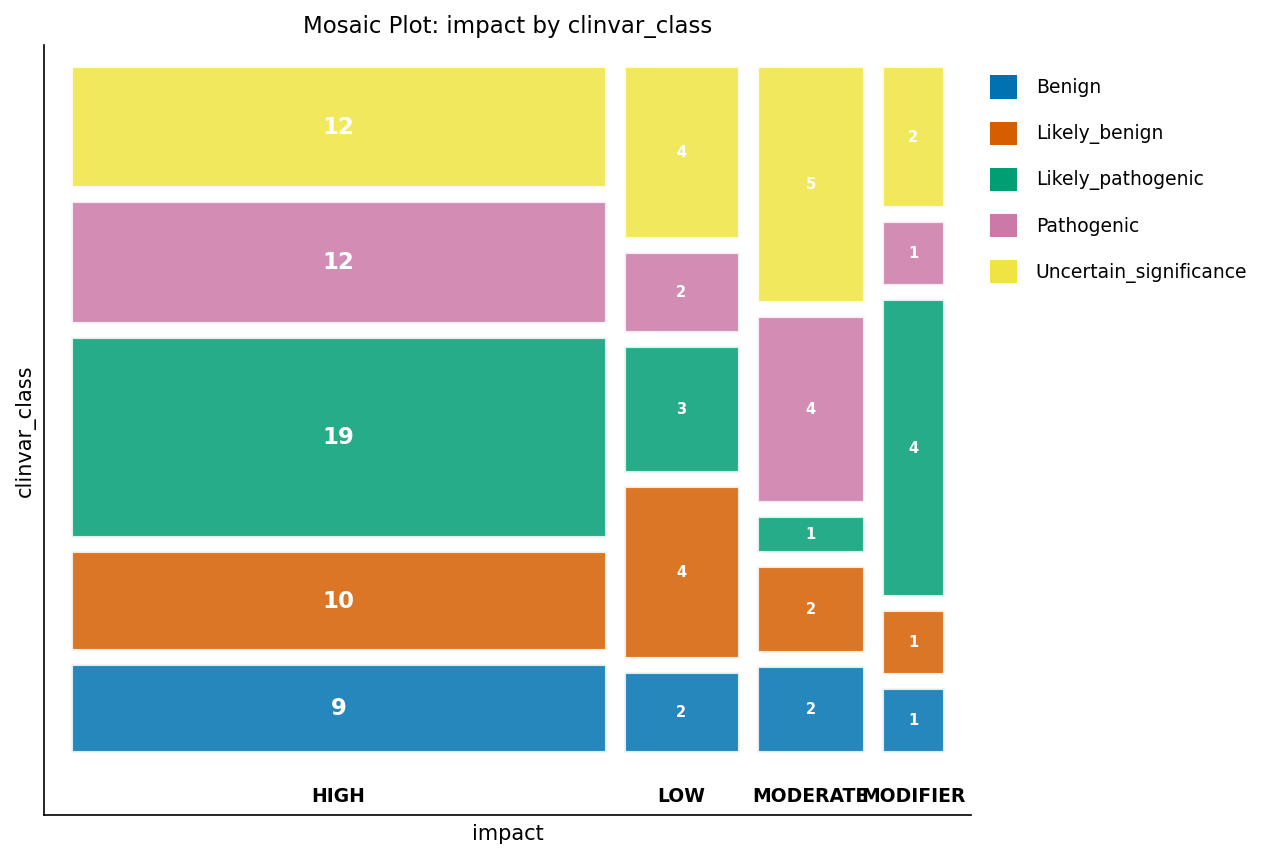

In [4]:
/* --------------------------------------------------------
   ベースラインのバリアントアノテーション集計
   -------------------------------------------------------- */
処理 度数 データ=variant_annotations;
    TABLES impact * clinvar_class / nocum;
    表題 'ClinVar 分類別のバリアント影響度';
実行;

処理 平均 データ=quality_metrics n mean MIN MAX;
    変数 mean_coverage ti_tv_ratio contamination_est;
    表題 'シーケンシング品質指標サマリー';
実行;

---

                                                    シーケンシング品質指標サマリー                                                     

                                                    シーケンシング品質指標サマリー                                                     




NOTE: PROC CONTENTS data=variant_annotations

NOTE: PROC CONTENTS: OUT=schema_lengths created with 25 variables
NOTE: PROC CONTENTS: data=variant_annotations obs=100 vars=25 (NOPRINT)
NOTE: DATA schema_lengths


NOTE: Read 25 rows from schema_lengths.
NOTE: Wrote schema_lengths (25 rows, 17 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=schema_lengths

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


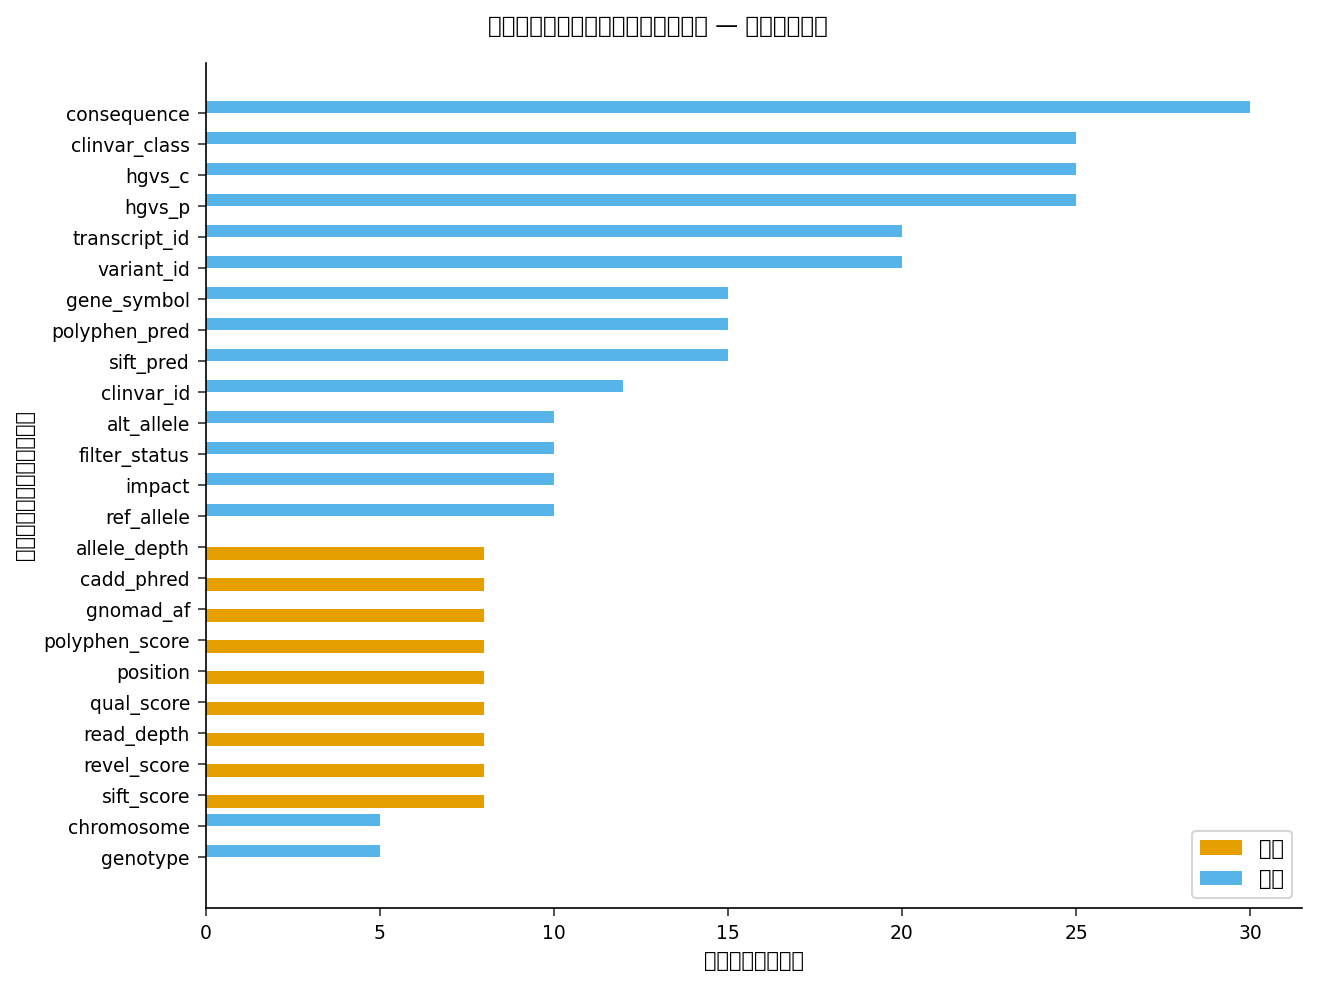

In [5]:
/* --------------------------------------------------------
   変数の型と長さの分布。
   PROC CONTENTS の OUT= でアノテーションスキーマの
   メタデータを取得し、型ごとにフィールド長を作図します。
   TYPE コードは凡例で 1 -> 数値、2 -> 文字 に対応します。
   -------------------------------------------------------- */
処理 内容 データ=variant_annotations out=schema_lengths NOPRINT;
実行;

データ schema_lengths;
    設定 schema_lengths;
    長さ type_label $9;
    もし TYPE = 1 なら type_label = '数値';
    他 type_label = '文字';
実行;

処理 SGPLOT データ=schema_lengths;
    HBAR NAME / RESPONSE=長さ GROUP=type_label
        CATEGORYORDER=respdesc;
    XAXIS 見出='変数長（バイト）';
    YAXIS 見出='アノテーションフィールド';
    表題 'バリアントアノテーションスキーマ — フィールド長';
実行;

---

In [6]:
/* --------------------------------------------------------
   PROC CONTENTS：バリアントアノテーションスキーマ全体を
   文書化 — 25 個すべてのフィールドの型・長さ・ラベル。
   OUT= で変数メタデータを取得し、下流のステップが
   スキーマをプログラム的に検証できるようにします。
   -------------------------------------------------------- */
処理 内容 データ=variant_annotations out=variant_schema NOPRINT;
実行;

処理 印刷 データ=variant_schema;
    変数 NAME TYPE 長さ VARNUM 見出;
    表題 'バリアントアノテーションデータセット — 完全スキーマ';
実行;

                                                    シーケンシング品質指標サマリー                                                     

                                              バリアントアノテーションデータセット — 完全スキーマ                                               

  Obs            NAME  TYPE  LENGTH  VARNUM                              LABEL
    1  allele_depth       1       8      22  変異アレルデプス
    2  alt_allele         2      10       5  変異アレル
    3  cadd_phred         1       8      19  CADD Phred スコア
    4  chromosome         2       5       2  染色体
    5  clinvar_class      2      25      13  ClinVar 分類
    6  clinvar_id         2      12      14  ClinVar 登録番号
    7  consequence        2      30       8  Sequence Ontology 影響
    8  filter_status      2      10      25  フィルターステータス
    9  gene_symbol        2      15       6  HGNC 遺伝子記号
   10  genotype           2       5      21  サンプル遺伝子型
   11  gnomad_af          1       8      12  gnomAD アレル頻度
   12  hgvs_c             2      25      10  HGVS コーディング表記



NOTE: PROC CONTENTS data=variant_annotations

NOTE: PROC CONTENTS: OUT=variant_schema created with 25 variables
NOTE: PROC CONTENTS: data=variant_annotations obs=100 vars=25 (NOPRINT)
NOTE: PROC PRINT data=variant_schema

NOTE: PROC PRINT completed: 25 observations printed, 5 variables


In [7]:
/* --------------------------------------------------------
   PROC CONTENTS：遺伝子パネルのスキーマを文書化
   -------------------------------------------------------- */
処理 内容 データ=gene_panel out=panel_schema NOPRINT;
実行;

処理 印刷 データ=panel_schema;
    変数 NAME TYPE 長さ VARNUM 見出;
    表題 '遺伝子パネル定義 — スキーマ';
実行;

                                              バリアントアノテーションデータセット — 完全スキーマ                                               

                                                    遺伝子パネル定義 — スキーマ                                                     

  Obs                 NAME  TYPE  LENGTH  VARNUM                     LABEL
    1  chromosome              2       5       3  染色体
    2  disease_association     2      50       7  関連疾患
    3  end_pos                 1       8       5  遺伝子終了位置
    4  gene_name               2      60       2  遺伝子正式名称
    5  gene_symbol             2      15       1  HGNC 遺伝子記号
    6  inheritance             2       5       8  遺伝形式
    7  panel_name              2      30       6  臨床遺伝子パネル
    8  start_pos               1       8       4  遺伝子開始位置




NOTE: PROC CONTENTS data=gene_panel

NOTE: PROC CONTENTS: OUT=panel_schema created with 8 variables
NOTE: PROC CONTENTS: data=gene_panel obs=15 vars=8 (NOPRINT)
NOTE: PROC PRINT data=panel_schema

NOTE: PROC PRINT completed: 8 observations printed, 5 variables


In [8]:
/* --------------------------------------------------------
   PROC CONTENTS：QC 指標のスキーマを文書化
   -------------------------------------------------------- */
処理 内容 データ=quality_metrics out=qc_schema NOPRINT;
実行;

処理 印刷 データ=qc_schema;
    変数 NAME TYPE 長さ VARNUM 見出;
    表題 'シーケンシング品質指標 — スキーマ';
実行;

                                                    遺伝子パネル定義 — スキーマ                                                     

                                                   シーケンシング品質指標 — スキーマ                                                   

  Obs               NAME  TYPE  LENGTH  VARNUM                                                 LABEL
    1  contamination_est     1       8      10  推定汚染率
    2  het_hom_ratio         1       8       9  ヘテロ/ホモ比
    3  mean_coverage         1       8       4  平均ターゲットカバレッジ
    4  pct_target_100x       1       8       6  100x 以上の塩基割合
    5  pct_target_20x        1       8       5  20x 以上の塩基割合
    6  platform              2      15       3  シーケンシングプラットフォーム
    7  qc_status             2      10      11  QC 合否ステータス
    8  run_id                2      12       2  シーケンシングラン ID
    9  sample_id             2      15       1  サンプル識別子
   10  ti_tv_ratio           1       8       8  トランジション/トランスバージョン比
   11  total_variants        1       8       7  コールされたバリ


NOTE: PROC CONTENTS data=quality_metrics

NOTE: PROC CONTENTS: OUT=qc_schema created with 11 variables
NOTE: PROC CONTENTS: data=quality_metrics obs=50 vars=11 (NOPRINT)
NOTE: PROC PRINT data=qc_schema

NOTE: PROC PRINT completed: 11 observations printed, 5 variables


In [9]:
/* --------------------------------------------------------
   スキーマ検証：アノテーションフィールドが ACMG 解釈の
   パイプライン要件を満たしているか確認します。
   PROC CONTENTS の OUT= メタデータを読み込みます。
   TYPE=1 は数値、TYPE=2 は文字を表します。
   -------------------------------------------------------- */
データ schema_validation;
    設定 variant_schema;
    長さ requirement $120 status $10;
    /* 数値スコアフィールドは数値型（TYPE=1）で格納する必要がある */
    もし NAME IN ('gnomad_af' 'sift_score' 'polyphen_score'
        'cadd_phred' 'revel_score' 'qual_score'
        'allele_depth' 'read_depth' 'position')
        かつ TYPE ne 1 なら 繰返;
        requirement = 'スコアしきい値のため数値型である必要があります';
        status = 'FAIL';
    終了;
    他 もし NAME IN ('gnomad_af' 'sift_score' 'polyphen_score'
        'cadd_phred' 'revel_score' 'qual_score'
        'allele_depth' 'read_depth' 'position')
        かつ TYPE = 1 なら 繰返;
        requirement = '数値型を確認';
        status = 'PASS';
    終了;
    /* ClinVar 分類には十分な文字長が必要 */
    他 もし NAME = 'clinvar_class' かつ 長さ < 25 なら 繰返;
        requirement = '完全な分類テキストのため最低 $25 が必要';
        status = 'FAIL';
    終了;
    他 もし NAME = 'clinvar_class' なら 繰返;
        requirement = '文字長は十分';
        status = 'PASS';
    終了;
    /* すべてのフィールドはデータディクショナリ用にラベルを持つ必要がある */
    他 もし 見出 = '' なら 繰返;
        requirement = 'データディクショナリのためラベルが必要';
        status = 'FAIL';
    終了;
    他 繰返;
        requirement = '一般検証';
        status = 'PASS';
    終了;
実行;

処理 印刷 データ=schema_validation;
    変数 NAME TYPE 長さ 見出 requirement status;
    表題 'ACMG パイプライン スキーマ検証レポート';
実行;

                                                 ACMG パイプライン スキーマ検証レポート                                                 

  Obs            NAME  TYPE  LENGTH                              LABEL         requirement  status
    1  allele_depth       1       8  変異アレルデプス                           数値型を確認              PASS
    2  alt_allele         2      10  変異アレル                              一般検証                PASS
    3  cadd_phred         1       8  CADD Phred スコア                     数値型を確認              PASS
    4  chromosome         2       5  染色体                                一般検証                PASS
    5  clinvar_class      2      25  ClinVar 分類                         文字長は十分              PASS
    6  clinvar_id         2      12  ClinVar 登録番号                       一般検証                PASS
    7  consequence        2      30  Sequence Ontology 影響               一般検証                PASS
    8  filter_status      2      10  フィルターステータス                         一般検証                PASS
   


NOTE: DATA schema_validation


NOTE: Read 25 rows from variant_schema.
NOTE: Wrote schema_validation (25 rows, 18 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=schema_validation

NOTE: PROC PRINT completed: 25 observations printed, 6 variables


---

### 解釈

バリアントアノテーションのスキーマには、ゲノム座標、機能予測、集団頻度、サンプルごとの品質指標にわたる 25 個のフィールドが含まれます。9 個の数値スコアフィールド（gnomAD アレル頻度、SIFT、PolyPhen-2、CADD、REVEL、品質スコア、アレルデプス、リードデプス、ゲノム位置）はすべて数値型として正しく型付けされており、ACMG 解釈エンジンが型変換なしにしきい値ベースのフィルタリングを適用できます。clinvar_class フィールドは $25 で、最も長い ClinVar 分類文字列（24 文字の Uncertain_significance）を収容できます。すべてのアノテーションフィールドに説明的なラベルが付与されており、CAP 認定要件のもとで臨床検査室のデータディクショナリ要件を満たしています。遺伝子パネルスキーマは、遺伝形式と疾患関連を伴う 15 個のがん易罹患性遺伝子をマッピングし、バリアントから遺伝子へのアノテーションの参照フレームワークを提供します。シーケンシング QC 指標データセットは、5 ラン分の 50 サンプルを文書化し、バリアントコールの信頼性を左右する汚染推定値とカバレッジしきい値を記録しています。このスキーマドキュメントパッケージは、ニューヨーク州 CLEP 提出に向けた検査室のバリデーション文書を支援します。

---

In [10]:
/* --------------------------------------------------------
   検査室認定のため、バリアントスキーマ文書と
   検証レポートをエクスポート
   -------------------------------------------------------- */
処理 EXPORT データ=variant_schema
    OUTFILE='variant_annotation_schema.csv'
    DBMS=csv REPLACE;
実行;

処理 EXPORT データ=schema_validation
    OUTFILE='acmg_schema_validation.csv'
    DBMS=csv REPLACE;
実行;


NOTE: PROC EXPORT data=variant_schema outfile=variant_annotation_schema.csv

NOTE: Exported 25 rows to variant_annotation_schema.csv.
NOTE: PROC EXPORT data=schema_validation outfile=acmg_schema_validation.csv

NOTE: Exported 25 rows to acmg_schema_validation.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; 社外秘
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
<a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a> によって提供
</div>
</div>